In [5]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
jumlah_data = 300

df = pd.DataFrame({
    "Income": np.random.normal(loc=60, scale=15, size=jumlah_data),
    "Spending": np.random.normal(loc=50, scale=20, size=jumlah_data)
})

scaler = StandardScaler()
X = scaler.fit_transform(df)

print("=" * 50)
print("HASIL EVALUASI JUMLAH CLUSTER")
print("=" * 50)

nilai_k = range(2, 11)
list_inertia = []
list_silhouette = []

for k in nilai_k:
    model = KMeans(n_clusters=k, random_state=42)
    cluster_label = model.fit_predict(X)

    inertia_value = model.inertia_
    silhouette_value = silhouette_score(X, cluster_label)

    list_inertia.append(inertia_value)
    list_silhouette.append(silhouette_value)

    print(f"K = {k:<2} | Inertia = {inertia_value:.2f} | Silhouette = {silhouette_value:.3f}")

k_optimal = nilai_k[list_silhouette.index(max(list_silhouette))]
print("\nK terbaik (berdasarkan Silhouette Score):", k_optimal)

final_kmeans = KMeans(n_clusters=k_optimal, random_state=42)
df["Cluster"] = final_kmeans.fit_predict(X)

print("\nData dengan Cluster:")
print(df.head())

HASIL EVALUASI JUMLAH CLUSTER
K = 2  | Inertia = 408.76 | Silhouette = 0.304
K = 3  | Inertia = 276.45 | Silhouette = 0.330
K = 4  | Inertia = 219.67 | Silhouette = 0.310
K = 5  | Inertia = 189.22 | Silhouette = 0.291
K = 6  | Inertia = 164.87 | Silhouette = 0.292
K = 7  | Inertia = 137.28 | Silhouette = 0.307
K = 8  | Inertia = 124.16 | Silhouette = 0.309
K = 9  | Inertia = 110.96 | Silhouette = 0.302
K = 10 | Inertia = 99.76 | Silhouette = 0.311

K terbaik (berdasarkan Silhouette Score): 3

Data dengan Cluster:
      Income   Spending  Cluster
0  67.450712  33.420100        0
1  57.926035  38.796379        0
2  69.715328  64.945872        1
3  82.845448  62.207405        1
4  56.487699  49.581968        2


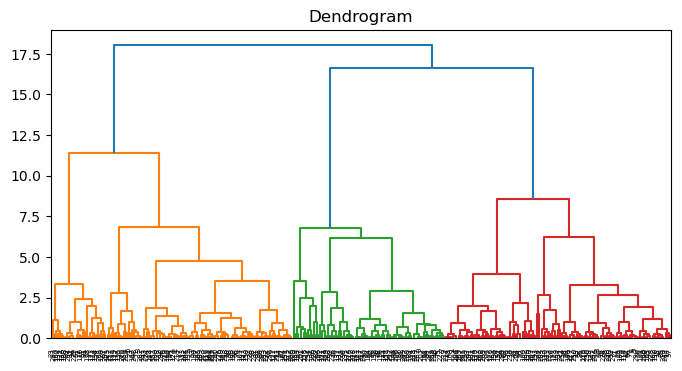

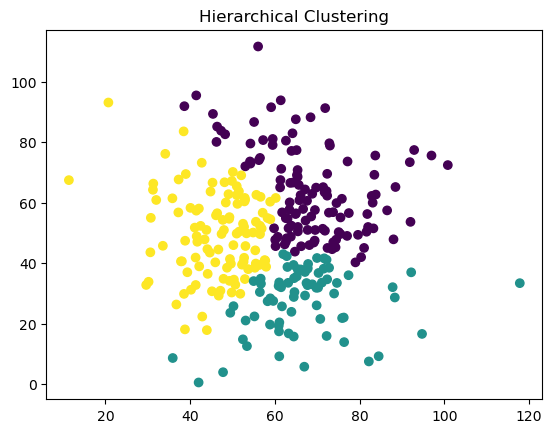

In [7]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X2 = scaler.fit_transform(df[["Income","Spending"]])

Z = linkage(X2, method="ward")

plt.figure(figsize=(8,4))
dendrogram(Z)
plt.title("Dendrogram")
plt.show()

n_cluster = 3
df["H_Cluster"] = fcluster(Z, n_cluster, criterion="maxclust")

plt.scatter(df["Income"], df["Spending"], c=df["H_Cluster"])
plt.title("Hierarchical Clustering")
plt.show()

In [8]:
from sklearn.metrics import silhouette_score

score_kmeans = silhouette_score(X, df["Cluster"])
score_hier = silhouette_score(X2, df["H_Cluster"])

print("Perbandingan Model")
print(f"K-Means Score      : {score_kmeans:.3f}")
print(f"Hierarchical Score : {score_hier:.3f}")

if score_kmeans > score_hier:
    print("K-Means lebih baik")
else:
    print("Hierarchical lebih baik")

Perbandingan Model
K-Means Score      : 0.306
Hierarchical Score : 0.306
Hierarchical lebih baik


        Segment  Total  Income_avg  Spending_avg
0    High Class    117   68.414321     63.382486
1    Low Budget     74   66.492888     27.849863
2  Middle Class    109   46.331030     49.490086

Segmen: High Class
Strategi: Fokus VIP & loyalty

Segmen: Low Budget
Strategi: Upselling

Segmen: Middle Class
Strategi: Diskon & promo


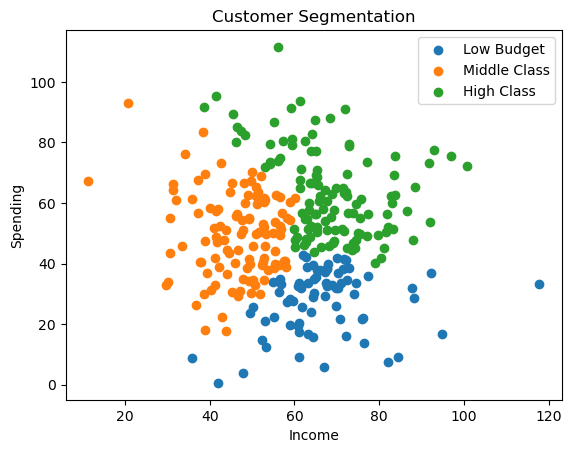

In [9]:
import matplotlib.pyplot as plt

seg_map = {
    1: "High Class",
    2: "Low Budget",
    3: "Middle Class"
}

df["Segment"] = df["Cluster"].map(seg_map)

summary = df.groupby("Segment").agg(
    Total=("Income","count"),
    Income_avg=("Income","mean"),
    Spending_avg=("Spending","mean")
).reset_index()

print(summary)

avg_i = df["Income"].mean()
avg_s = df["Spending"].mean()

for i in range(len(summary)):
    seg = summary.loc[i,"Segment"]
    inc = summary.loc[i,"Income_avg"]
    spd = summary.loc[i,"Spending_avg"]

    print(f"\nSegmen: {seg}")

    if inc > avg_i and spd > avg_s:
        print("Strategi: Fokus VIP & loyalty")
    elif inc < avg_i and spd < avg_s:
        print("Strategi: Diskon & promo")
    elif inc > avg_i:
        print("Strategi: Upselling")
    else:
        print("Strategi: Promosi terarah")

for s in df["Segment"].unique():
    d = df[df["Segment"] == s]
    plt.scatter(d["Income"], d["Spending"], label=s)

plt.legend()
plt.title("Customer Segmentation")
plt.xlabel("Income")
plt.ylabel("Spending")
plt.show()